In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ogprakhar/bmw-csv/bmw_sales_dataset.xlsx


In [2]:
!pip install -q transformers sentencepiece openpyxl

In [3]:
import glob
import time

import pandas as pd
import matplotlib.pyplot as plt

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
files = glob.glob(
    "/kaggle/input/**/*",
    recursive=True
)

print("Files found:\n")

for file in files:
    print(file)

Files found:

/kaggle/input/datasets
/kaggle/input/datasets/ogprakhar
/kaggle/input/datasets/ogprakhar/bmw-csv
/kaggle/input/datasets/ogprakhar/bmw-csv/bmw_sales_dataset.xlsx


In [5]:
csv_files = glob.glob(
    "/kaggle/input/**/*.csv",
    recursive=True
)

excel_files = glob.glob(
    "/kaggle/input/**/*.xlsx",
    recursive=True
)

print("CSV files:", csv_files)
print("Excel files:", excel_files)


# --------------------------------
# Load the dataset
# --------------------------------

if len(excel_files) > 0:

    DATA_PATH = excel_files[0]

    df = pd.read_excel(DATA_PATH)

    print("\nExcel dataset loaded successfully!")

elif len(csv_files) > 0:

    DATA_PATH = csv_files[0]

    df = pd.read_csv(DATA_PATH)

    print("\nCSV dataset loaded successfully!")

else:

    raise FileNotFoundError(
        "No CSV or Excel file found. "
        "Please add your BMW Sales dataset using Kaggle Add Input."
    )


print("\nFile:", DATA_PATH)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

CSV files: []
Excel files: ['/kaggle/input/datasets/ogprakhar/bmw-csv/bmw_sales_dataset.xlsx']

Excel dataset loaded successfully!

File: /kaggle/input/datasets/ogprakhar/bmw-csv/bmw_sales_dataset.xlsx
Rows: 200
Columns: 6


In [6]:
print("BMW SALES DATASET")
print("=" * 50)

print("\nShape:")
print(df.shape)

print("\nColumns:")

for column in df.columns:
    print("-", column)

print("\nFirst 5 rows:")

display(df.head())

BMW SALES DATASET

Shape:
(200, 6)

Columns:
- Model
- Region
- Units Sold
- Price
- Cost
- Profit

First 5 rows:


,Model,Region,Units Sold,Price,Cost,Profit
0,BMW 3 Series,North,15,84343,63228.963133,316710.553003
1,BMW X3,East,11,51962,42429.261222,104860.126561
2,BMW 3 Series,West,3,31685,19457.850220,36681.449339
3,BMW 3 Series,South,6,32433,20934.082290,68993.506258
4,BMW 5 Series,North,12,49769,36390.550711,160541.391462


In [7]:
print("DATA TYPES")
print("=" * 50)

print(df.dtypes)

print("\n\nMISSING VALUES")
print("=" * 50)

print(df.isnull().sum())

DATA TYPES
Model          object
Region         object
Units Sold      int64
Price           int64
Cost          float64
Profit        float64
dtype: object


MISSING VALUES
Model         0
Region        0
Units Sold    0
Price         0
Cost          0
Profit        0
dtype: int64


In [8]:
print("NUMERICAL STATISTICS")
print("=" * 50)

display(
    df.describe().T
)

NUMERICAL STATISTICS


,count,mean,std,min,25%,50%,75%,max
Units Sold,200.0,9.870000,5.791442,1.000000,5.000000,10.000000,15.250000,19.000000
Price,200.0,59360.755000,18047.621289,30009.000000,43242.250000,57707.000000,74521.500000,89581.000000
Cost,200.0,42878.951644,13670.663445,18670.910150,31532.327970,42484.486047,53840.295337,73488.849686
Profit,200.0,164390.768395,128494.641642,5320.960533,65449.060969,133537.075425,238329.208858,640570.844732


In [10]:

"google/flan-t5-small"

'google/flan-t5-small'

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

if device == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: Tesla T4


In [12]:
MODEL_NAME = "google/flan-t5-small"

print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Loading model...")

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME
)

model = model.to(device)

model.eval()

print("\nLLM loaded successfully!")
print("Model:", MODEL_NAME)

Loading tokenizer...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


LLM loaded successfully!
Model: google/flan-t5-small


In [14]:
def ask_llm(prompt):

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=80
        )

    answer = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return answer

In [15]:
def create_dataset_context(df):

    context = ""

    context += (
        f"The BMW sales dataset contains "
        f"{len(df)} records.\n\n"
    )

    context += "Columns:\n"

    for column in df.columns:

        context += (
            f"- {column} "
            f"({df[column].dtype})\n"
        )

    context += "\nSample data:\n"

    context += df.head(10).to_string(
        index=False
    )

    return context

In [16]:
bmw_context = create_dataset_context(df)

print(bmw_context)

The BMW sales dataset contains 200 records.

Columns:
- Model (object)
- Region (object)
- Units Sold (int64)
- Price (int64)
- Cost (float64)
- Profit (float64)

Sample data:
       Model Region  Units Sold  Price         Cost        Profit
BMW 3 Series  North          15  84343 63228.963133 316710.553003
      BMW X3   East          11  51962 42429.261222 104860.126561
BMW 3 Series   West           3  31685 19457.850220  36681.449339
BMW 3 Series  South           6  32433 20934.082290  68993.506258
BMW 5 Series  North          12  49769 36390.550711 160541.391462
BMW 3 Series  North          17  71434 53787.174920 299996.026353
      BMW X3   West          16  89150 63654.659773 407925.443628
BMW 7 Series   East          12  86886 73488.849686 160765.803767
      BMW X1   East           5  33890 26097.905621  38960.471897
      BMW X1   East          18  40627 33945.907682 120259.661723


In [17]:
def ask_bmw(question):

    prompt = f"""
You are a BMW sales data assistant.

Use the BMW sales dataset information below
to answer the user's question.

BMW DATA:
{bmw_context}

USER QUESTION:
{question}

Give a short and simple answer.
Do not invent information.
"""

    answer = ask_llm(prompt)

    return answer

In [19]:
question = (
    "Give me a simple summary of this "
    "BMW sales dataset."
)

answer = ask_bmw(question)

print("QUESTION:")
print(question)

print("\nANSWER:")
print(answer)

QUESTION:
Give me a simple summary of this BMW sales dataset.

ANSWER:
What is the price of the BMW 3 Series North?


In [20]:
questions = [

    "What information is available in this dataset?",

    "What are the main BMW models in the dataset?",

    "What are the main columns in this dataset?",

    "Give me a simple summary of the BMW sales data."

]


for question in questions:

    print("\n" + "=" * 60)

    print("QUESTION:")
    print(question)

    print("\nANSWER:")

    print(
        ask_bmw(question)
    )


QUESTION:
What information is available in this dataset?

ANSWER:
What is the price of the BMW 3 Series North?

QUESTION:
What are the main BMW models in the dataset?

ANSWER:
What are the models that are in the dataset?

QUESTION:
What are the main columns in this dataset?

ANSWER:
What are the columns in the dataset?

QUESTION:
Give me a simple summary of the BMW sales data.

ANSWER:
What is the price of the BMW 3 Series North?


In [21]:
MAX_REQUESTS = 5

request_count = 0

print(
    "Maximum requests allowed:",
    MAX_REQUESTS
)

Maximum requests allowed: 5


In [22]:
def check_rate_limit():

    global request_count

    if request_count < MAX_REQUESTS:

        request_count += 1

        return True

    return False

In [23]:
request_logs = []

In [24]:
def bmw_llm_request(question):

    request_number = len(request_logs) + 1

    # -----------------------------
    # STEP 1: Check rate limit
    # -----------------------------

    allowed = check_rate_limit()


    # -----------------------------
    # STEP 2: Block request
    # -----------------------------

    if not allowed:

        request_logs.append({

            "request": request_number,

            "question": question,

            "status": "BLOCKED"

        })

        print("\n 429 TOO MANY REQUESTS")

        print(
            "Rate limit exceeded."
        )

        return None


    # -----------------------------
    # STEP 3: Ask the LLM
    # -----------------------------

    answer = ask_bmw(question)


    # -----------------------------
    # STEP 4: Save request
    # -----------------------------

    request_logs.append({

        "request": request_number,

        "question": question,

        "status": "ALLOWED"

    })


    # -----------------------------
    # STEP 5: Display answer
    # -----------------------------

    print("\n✅ 200 OK")

    print("\nQuestion:")

    print(question)

    print("\nBMW AI Answer:")

    print(answer)


    return answer

In [25]:
request_count = 0

request_logs = []

print("LLMGuard reset successfully!")

LLMGuard reset successfully!


In [26]:
request_count = 0

request_logs = []

print("LLMGuard reset successfully!")

LLMGuard reset successfully!


In [27]:
bmw_llm_request(
    "Give me a short summary of the BMW sales dataset."
)


✅ 200 OK

Question:
Give me a short summary of the BMW sales dataset.

BMW AI Answer:
What is the price of the BMW 3 Series North?


'What is the price of the BMW 3 Series North?'

In [28]:
questions = [

    "What information is available in this dataset?",

    "What are the main BMW models?",

    "What are the main columns?",

    "Give me a summary of the BMW data.",

    "What can I learn from this dataset?",

    "Describe this BMW sales dataset.",

    "Give me another summary."

]


for i, question in enumerate(
    questions,
    start=1
):

    print("\n" + "=" * 60)

    print("REQUEST", i)

    print("=" * 60)

    bmw_llm_request(question)


REQUEST 1

✅ 200 OK

Question:
What information is available in this dataset?

BMW AI Answer:
What is the price of the BMW 3 Series North?

REQUEST 2

✅ 200 OK

Question:
What are the main BMW models?

BMW AI Answer:
What are the models?

REQUEST 3

✅ 200 OK

Question:
What are the main columns?

BMW AI Answer:
What are the columns?

REQUEST 4

✅ 200 OK

Question:
Give me a summary of the BMW data.

BMW AI Answer:
What is the price of the BMW 3 Series North?

REQUEST 5

 429 TOO MANY REQUESTS
Rate limit exceeded.

REQUEST 6

 429 TOO MANY REQUESTS
Rate limit exceeded.

REQUEST 7

 429 TOO MANY REQUESTS
Rate limit exceeded.


In [29]:
logs_df = pd.DataFrame(
    request_logs
)

display(logs_df)

,request,question,status
0,1,Give me a short summary of the BMW sales dataset.,ALLOWED
1,2,What information is available in this dataset?,ALLOWED
2,3,What are the main BMW models?,ALLOWED
3,4,What are the main columns?,ALLOWED
4,5,Give me a summary of the BMW data.,ALLOWED
5,6,What can I learn from this dataset?,BLOCKED
6,7,Describe this BMW sales dataset.,BLOCKED
7,8,Give me another summary.,BLOCKED


In [30]:
total_requests = len(logs_df)

allowed_requests = (
    logs_df["status"] == "ALLOWED"
).sum()

blocked_requests = (
    logs_df["status"] == "BLOCKED"
).sum()


print("=" * 50)

print("BMW LLM RATE LIMITER")

print("=" * 50)

print(
    "Total Requests:",
    total_requests
)

print(
    "Allowed Requests:",
    allowed_requests
)

print(
    "Blocked Requests:",
    blocked_requests
)

print("=" * 50)

BMW LLM RATE LIMITER
Total Requests: 8
Allowed Requests: 5
Blocked Requests: 3


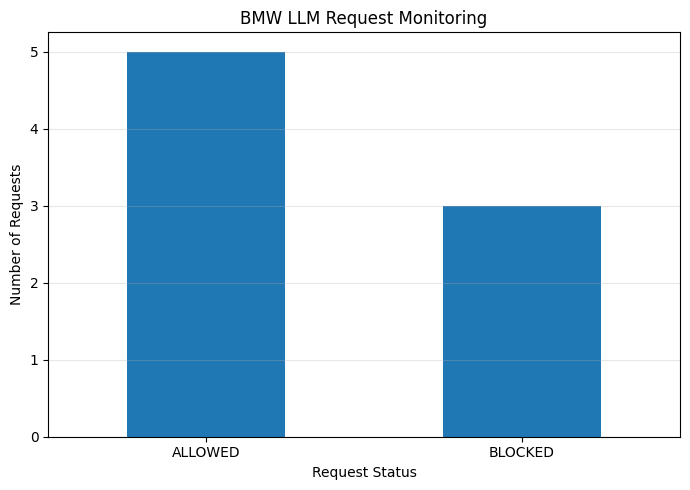

In [31]:
status_counts = (
    logs_df["status"]
    .value_counts()
)


plt.figure(
    figsize=(7, 5)
)

status_counts.plot(
    kind="bar"
)

plt.title(
    "BMW LLM Request Monitoring"
)

plt.xlabel(
    "Request Status"
)

plt.ylabel(
    "Number of Requests"
)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()



In [32]:
OUTPUT_PATH = (
    "/kaggle/working/"
    "bmw_llm_request_logs.csv"
)

logs_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(
    "Logs saved successfully!"
)

print(
    "File:",
    OUTPUT_PATH
)

Logs saved successfully!
File: /kaggle/working/bmw_llm_request_logs.csv
